# 04. Bias Case Studies

## 📚 Learning Objectives

By completing this notebook, you will:
- Analyze bias incidents in real AI systems
- Extract root causes and remedies
- Connect case studies to detection and mitigation

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lesson 02 "Decision Trees and Random Forest" — the model families behind most of the incidents examined here.

---


# 04. Bias Case Studies

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - Understanding how to detect bias
- ✅ **Example 2: Bias Mitigation** - Understanding mitigation techniques
- ✅ **Example 3: Fair Representation** - Understanding fair representation
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts

**If you haven't completed these**, you might struggle with:
- Understanding real-world bias scenarios
- Analyzing bias in different contexts
- Applying detection and mitigation techniques to real cases

---

## 🔗 Where This Notebook Fits

**This is the FOURTH example in Unit 2** - it teaches you how to analyze real-world bias cases!

**Why this example FOURTH?**
- **Before** you can analyze real cases, you need to understand detection (Example 1)
- **Before** you can understand solutions, you need to know mitigation (Example 2)
- **Before** you can analyze cases deeply, you need fair representation (Example 3)

**Builds on**: 
- 📓 Example 1: Bias Detection (we know how to detect bias)
- 📓 Example 2: Bias Mitigation (we know how to fix bias)
- 📓 Example 3: Fair Representation (we know how to ensure fair features)

**Leads to**: 
- 📓 Example 5: Fair AI Development (building fair AI systems from the start!)

**Why this order?**
1. Case studies provide **real-world context** (needed after learning techniques)
2. Case studies teach **analysis skills** (critical for practitioners)
3. Case studies show **different domains** (facial recognition, hiring, policing, credit)

---

## The Story: Learning from Real Mistakes

Imagine you're a medical student. **Before** you can treat patients, you need to study real cases - see what worked, what didn't, learn from mistakes. **After** studying cases, you understand patterns and can apply lessons to new situations!

Same with AI bias: **Before** we learned techniques, now we study real cases - facial recognition bias, hiring discrimination, predictive policing issues. **After** case studies, we understand how bias manifests in practice!

---

## Why Case Studies Matter

Case studies are essential for ethical AI:
- **Real-World Context**: See how bias manifests in practice
- **Learn from Mistakes**: Understand what went wrong and why
- **Pattern Recognition**: Identify common bias patterns across domains
- **Practical Application**: Apply detection and mitigation to real scenarios
- **Prevention**: Learn how to avoid similar issues in your own work

## Learning Objectives
1. Analyze bias in facial recognition systems
2. Analyze gender bias in hiring algorithms
3. Analyze bias in predictive policing systems
4. Analyze discrimination in credit scoring
5. Identify common patterns across different bias cases
6. Apply detection and mitigation techniques to real scenarios

## 📌 The case that made every number in this notebook possible

**Buolamwini & Gebru, *Gender Shades*, FAT\* 2018.** Three shipped commercial
gender-classification APIs — Microsoft, Face++ and IBM — were bought and compared on a single
headline accuracy figure. Two researchers built a purpose-made benchmark (the **Pilot
Parliaments Benchmark**, 1,270 parliamentarians balanced for skin type and gender), ran the
APIs, and **disaggregated the result**. Measured on that benchmark the three systems erred
overall on 6.3 %, 10.0 % and 12.1 % of faces; IBM's error rate on darker-skinned women was
**34.7 %**. Nothing had been hidden; nobody had grouped the numbers.

**It was replicated at national scale.** In **December 2019** the US National Institute of
Standards and Technology published **NISTIR 8280** (*FRVT Part 3: Demographic Effects*):
**189 algorithms from 99 developers**, run over **18.27 million images of 8.49 million
people** from four operational US government datasets. Its headline finding is blunter than
*Gender Shades*: across demographic groups, **false-positive rates often vary by factors of
10 to beyond 100**; false positives were highest for West and East African and East Asian
faces on application photos, highest for American Indians on domestic mugshots, consistently
higher for women than men, and elevated for children and the elderly.

That is the difference between an activist claim and an engineering fact: one paper, then a
government test lab, same result.

**The WHY — what goes wrong without case studies like these.** Each of the four cases in
this notebook fails in a *different mechanism*, and only one of them is "the model has a
biased coefficient". If the only failure mode you can recognise is the one in the textbook,
you will pass an audit and ship the other three.

**And one case we cannot run.** The most-cited hiring failure is the experimental
résumé-screening engine Reuters reported **Amazon** abandoning in October 2018, after it
learned from a male-dominated hiring record to downgrade résumés containing "women's". That
tool's data was never released — which is itself a fact about this field. So Case Study 2
below uses a real selection decision that *was* fully recorded, with a real confound
attached, because that is the situation a working auditor is actually in.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** Four **real** sources - no invented people anywhere in this notebook

1. **Buolamwini & Gebru (2018), *Gender Shades*, Table 4** - the published, per-subgroup
   error rates of three commercial gender classifiers. Transcribed verbatim from the paper.
2. `load("titanic")` - 891 real passengers; a real life-and-death selection decision
   recorded by sex and ticket class. The whole file ships with this repository.
3. `load("montgomery_911_calls", prefer="sample")` - real emergency dispatch records
   from Montgomery County, PA, used to drive a patrol-allocation feedback loop from
   genuine call volumes. The 123 MB original is not in the repository; the bundled
   **25,000-row sample** keeps one row in every 27, evenly spread, so it spans the same
   2015-2020 window and all 68 townships.
4. `load("creditcard_fraud", prefer="sample")` - real card transactions with real fraud
   labels; we audit who a fraud model actually protects. The 151 MB original is not in
   the repository; the bundled **16,000-row sample** preserves the fraud rate
   (0.175 % against 0.173 %), which leaves **28 frauds in total** - and how few that is
   turns out to be the point of the case study.

`prefer="sample"` is deliberate on the two large files: it pins them to the copy every
clone contains, so **every number in this notebook is reproducible on any machine**,
with or without a Kaggle account. Each `load` prints which copy it used.

**Outputs:** What you'll see when you run the cells

- Intersectional error rates that a headline accuracy number completely hides
- A real selection disparity, and the confound that complicates reading it
- A feedback loop that concentrates patrols on real call data with no change in real risk
- A fraud model whose false-positive rate looks fair while its detection rate is not

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us analyze real-world bias case studies

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.metrics import accuracy_score, confusion_matrix  # For model evaluation: Performance metrics
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (models, metrics)")
print("   - os: File operations (saving images)")


✅ Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (models, metrics)
   - os: File operations (saving images)


## Part 2: Case Study 1 - Facial Recognition Bias

### 📖 The Story
**Before case study**: We know bias exists but haven't seen it measured in a shipped product.
**After case study**: We have the published audit numbers in front of us.

> **These are real published measurements.** Every figure in the next cell is transcribed
> from **Table 4 of Buolamwini, J. & Gebru, T. (2018), *Gender Shades: Intersectional
> Accuracy Disparities in Commercial Gender Classification*, PMLR 81** - an audit of three
> commercial gender-classification APIs on the Pilot Parliaments Benchmark (PPB), a
> purpose-built dataset of parliamentarians balanced for skin type and gender.
> Column labels follow the paper: **DF** darker female, **DM** darker male,
> **LF** lighter female, **LM** lighter male.
>
> Nothing here is simulated. This is what an audit report looks like.

In [3]:
# Why this case: it is the audit that made algorithmic bias measurable. The numbers
# below are transcribed from the published paper - not simulated, not illustrative.

# Step 2: Read the real Gender Shades audit table

print("\n" + "="*80)
print("📊 CASE STUDY 1: Gender Shades (Buolamwini & Gebru, 2018) - PUBLISHED DATA")
print("="*80)

# Table 4, "Error Rate (%)" rows, verbatim from the paper.
# Columns: All | F | M | Darker | Lighter | DF | DM | LF | LM
gender_shades = pd.DataFrame(
    [[6.3, 10.7, 2.6, 12.9, 0.7, 20.8, 6.0, 1.7, 0.0],
     [10.0, 21.3, 0.7, 16.5, 4.7, 34.5, 0.7, 9.8, 0.8],
     [12.1, 20.3, 5.6, 22.4, 3.2, 34.7, 12.0, 7.1, 0.3]],
    index=['Microsoft', 'Face++', 'IBM'],
    columns=['All', 'Female', 'Male', 'Darker', 'Lighter', 'DF', 'DM', 'LF', 'LM'])

print("\nGender classification ERROR RATE (%) on the PPB benchmark")
print("(lower is better; source: Gender Shades Table 4)\n")
print(gender_shades.to_string())

print("\n" + "-"*80)
print("WHAT THE HEADLINE NUMBER HIDES")
print("-"*80)
for clf in gender_shades.index:
    row = gender_shades.loc[clf]
    print(f"\n{clf}:")
    print(f"  Overall error rate                : {row['All']:.1f}%  <- the number in the brochure")
    print(f"  Darker-skinned female error rate  : {row['DF']:.1f}%")
    print(f"  Lighter-skinned male error rate   : {row['LM']:.1f}%")
    gap = row['DF'] - row['LM']
    print(f"  Intersectional gap (DF - LM)      : {gap:.1f} percentage points")
    if row['LM'] > 0:
        print(f"  Ratio                             : {row['DF']/row['LM']:.0f}x more errors")
    else:
        print(f"  Ratio                             : undefined - the classifier made "
              f"ZERO errors on lighter-skinned males")

worst = gender_shades['DF'].idxmax()
print(f"\nWorst single subgroup result in the table: {worst} on darker-skinned")
print(f"females, {gender_shades.loc[worst, 'DF']:.1f}% error - while the same system reports")
print(f"{gender_shades.loc[worst, 'All']:.1f}% error overall.")

print("\n💡 THE LESSON: single-axis auditing is not enough. Splitting by gender alone,")
print("   or by skin type alone, understates the harm. The failure lives at the")
print("   INTERSECTION - which is exactly the subgroup a one-dimensional fairness")
print("   report never looks at.")


📊 CASE STUDY 1: Gender Shades (Buolamwini & Gebru, 2018) - PUBLISHED DATA

Gender classification ERROR RATE (%) on the PPB benchmark
(lower is better; source: Gender Shades Table 4)

            All  Female  Male  Darker  Lighter    DF    DM   LF   LM
Microsoft   6.3    10.7   2.6    12.9      0.7  20.8   6.0  1.7  0.0
Face++     10.0    21.3   0.7    16.5      4.7  34.5   0.7  9.8  0.8
IBM        12.1    20.3   5.6    22.4      3.2  34.7  12.0  7.1  0.3

--------------------------------------------------------------------------------
WHAT THE HEADLINE NUMBER HIDES
--------------------------------------------------------------------------------

Microsoft:
  Overall error rate                : 6.3%  <- the number in the brochure
  Darker-skinned female error rate  : 20.8%
  Lighter-skinned male error rate   : 0.0%
  Intersectional gap (DF - LM)      : 20.8 percentage points
  Ratio                             : undefined - the classifier made ZERO errors on lighter-skinned males

Face

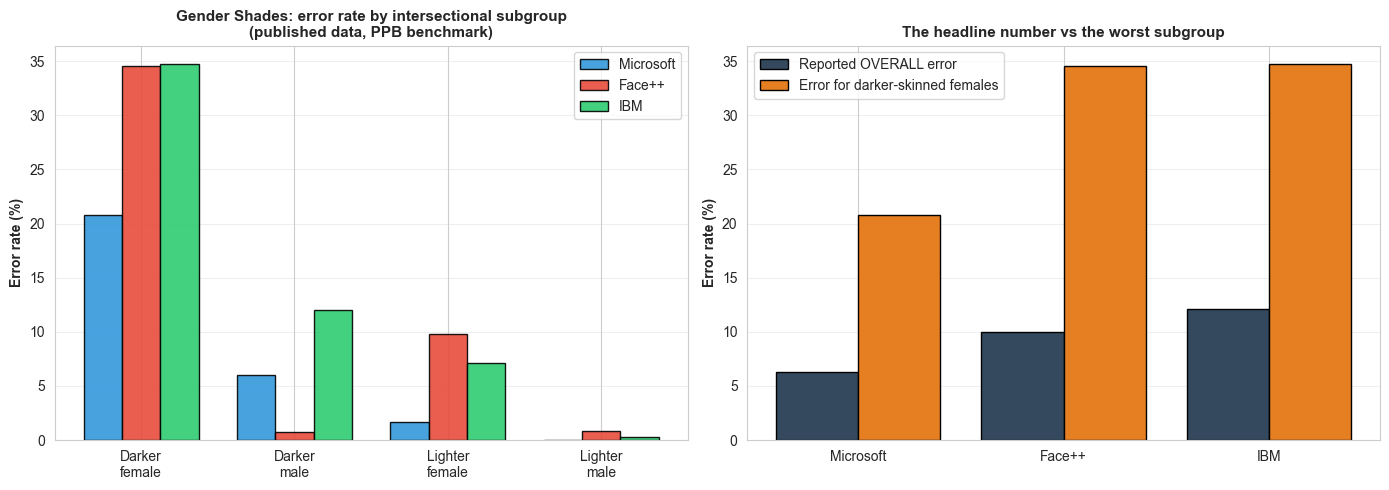

Across the three audited systems the average REPORTED error was 9.5%,
while the average error for darker-skinned females was 30.0% -
a factor of 3.2x. A product that ships on the first number
is shipping the second number to real people.


In [4]:
# Why visualize: the gap between the aggregate bar and the DF bar is the entire
# argument of the Gender Shades paper - one chart makes it undeniable.

# Chart the real audit: overall error vs the four intersectional subgroups
subgroups = ['DF', 'DM', 'LF', 'LM']
labels = ['Darker\nfemale', 'Darker\nmale', 'Lighter\nfemale', 'Lighter\nmale']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(subgroups)); width = 0.25
for i, (clf, color) in enumerate(zip(gender_shades.index,
                                     ['#3498db', '#e74c3c', '#2ecc71'])):
    axes[0].bar(x + (i - 1) * width, gender_shades.loc[clf, subgroups].values,
                width, label=clf, color=color, alpha=0.9, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Error rate (%)', fontweight='bold')
axes[0].set_title('Gender Shades: error rate by intersectional subgroup\n'
                  '(published data, PPB benchmark)', fontsize=11, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Right: the headline number next to the worst subgroup, per classifier.
x2 = np.arange(len(gender_shades))
axes[1].bar(x2 - 0.2, gender_shades['All'].values, 0.4,
            label='Reported OVERALL error', color='#34495e', edgecolor='black')
axes[1].bar(x2 + 0.2, gender_shades['DF'].values, 0.4,
            label='Error for darker-skinned females', color='#e67e22', edgecolor='black')
axes[1].set_xticks(x2); axes[1].set_xticklabels(gender_shades.index)
axes[1].set_ylabel('Error rate (%)', fontweight='bold')
axes[1].set_title('The headline number vs the worst subgroup',
                  fontsize=11, fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Computed reading of the chart:
avg_all = gender_shades['All'].mean()
avg_df = gender_shades['DF'].mean()
print(f"Across the three audited systems the average REPORTED error was {avg_all:.1f}%,")
print(f"while the average error for darker-skinned females was {avg_df:.1f}% -")
print(f"a factor of {avg_df/avg_all:.1f}x. A product that ships on the first number")
print(f"is shipping the second number to real people.")

## Part 3: Case Study 2 - Selection Bias in a Real Life-or-Death Decision

The hiring-algorithm story most people know is the internal recruiting tool a large tech
company scrapped in 2018 after it penalised résumés mentioning "women's". We cannot use
that tool's data - it was never released.

So we use a **real selection decision that was fully recorded**: the Titanic evacuation.
Who received a place in a lifeboat is documented for 891 passengers, along with sex, ticket
class, age and fare. The disparity is real, large, and - crucially - **confounded**, which
is exactly the situation a working auditor faces.

In [5]:
# Why this case: a real, fully recorded selection decision - and a real confound.
# Auditing means measuring the gap AND being honest about what could explain it.

# Step 3: Audit a real selection decision (Titanic evacuation)

print("\n" + "="*80)
print("CASE STUDY 2: Selection Bias in a Real Recorded Decision")
print("="*80)

df_sel = load("titanic")
df_sel['Age'] = df_sel['Age'].fillna(df_sel['Age'].median())
print(f"\nReal records analysed: {len(df_sel)} passengers")

print("\nSelection rate (survived the evacuation) by sex:")
by_sex = df_sel.groupby('Sex')['Survived'].agg(['mean', 'count'])
for sex, row in by_sex.iterrows():
    print(f"  {sex:<8}: {row['mean']:.2%}   (n={int(row['count'])})")
sex_gap = by_sex['mean'].max() - by_sex['mean'].min()
print(f"\n  Disparity: {sex_gap:.2%}")

print("\nSelection rate by ticket class (socio-economic status):")
by_class = df_sel.groupby('Pclass')['Survived'].agg(['mean', 'count'])
for pc, row in by_class.iterrows():
    print(f"  Class {pc}: {row['mean']:.2%}   (n={int(row['count'])})")
class_gap = by_class['mean'].max() - by_class['mean'].min()
print(f"\n  Disparity: {class_gap:.2%}")

print("\n" + "-"*80)
print("INTERSECTIONAL VIEW - the lesson Case Study 1 just taught us")
print("-"*80)
cross = df_sel.pivot_table(index='Sex', columns='Pclass', values='Survived',
                           aggfunc='mean')
counts = df_sel.pivot_table(index='Sex', columns='Pclass', values='Survived',
                            aggfunc='count')
print("\nSurvival rate by sex x class:")
print((cross * 100).round(1).to_string())
print("\nGroup sizes:")
print(counts.to_string())

best_cell = cross.stack().idxmax(); worst_cell = cross.stack().idxmin()
print(f"\nBest-off subgroup : {best_cell[0]}, class {best_cell[1]} "
      f"-> {cross.stack().max():.1%} survived")
print(f"Worst-off subgroup: {worst_cell[0]}, class {worst_cell[1]} "
      f"-> {cross.stack().min():.1%} survived")
print(f"Intersectional gap: {cross.stack().max() - cross.stack().min():.1%}")

print("\n⚠️  THE CONFOUND - and why this case study is more useful than a simulation:")
print("   'Women and children first' was the STATED evacuation policy. Part of the")
print("   sex gap is that explicit rule, not hidden prejudice. But the CLASS gap has")
print("   no such justification, and the intersectional table shows the two")
print("   interacting: read off how a third-class woman fared against a first-class one.")
print("\n   A simulated dataset would have handed you one clean cause. Real data")
print("   hands you several tangled ones, and the auditor's job is to say which")
print("   part of the gap has a legitimate explanation and which part does not.")


CASE STUDY 2: Selection Bias in a Real Recorded Decision
titanic: full file, 891 rows.

Real records analysed: 891 passengers

Selection rate (survived the evacuation) by sex:
  female  : 74.20%   (n=314)
  male    : 18.89%   (n=577)

  Disparity: 55.31%

Selection rate by ticket class (socio-economic status):
  Class 1: 62.96%   (n=216)
  Class 2: 47.28%   (n=184)
  Class 3: 24.24%   (n=491)

  Disparity: 38.73%

--------------------------------------------------------------------------------
INTERSECTIONAL VIEW - the lesson Case Study 1 just taught us
--------------------------------------------------------------------------------

Survival rate by sex x class:
Pclass     1     2     3
Sex                     
female  96.8  92.1  50.0
male    36.9  15.7  13.5

Group sizes:
Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  347

Best-off subgroup : female, class 1 -> 96.8% survived
Worst-off subgroup: male, class 3 -> 13.5% survived
Intersectional gap

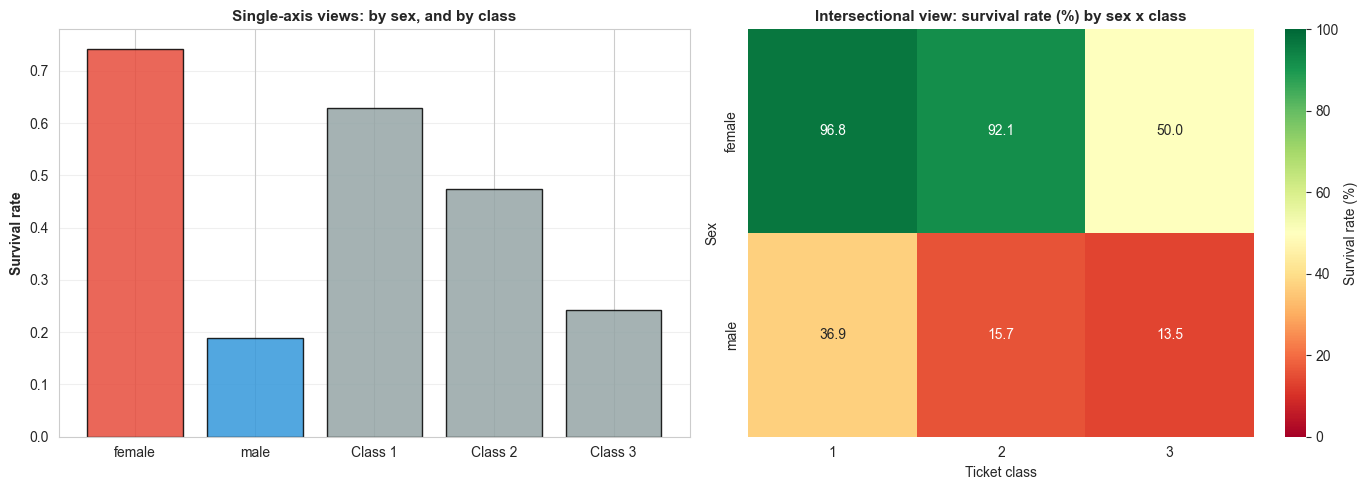

Read the heatmap against the bars on the left: a third-class woman survived
50.0% of the time and a first-class man 36.9%. Neither single-axis
chart on the left contains that comparison - the sex bars say women did
better, the class bars say first class did better, and only the
intersection tells you what happened to a person who was both.


In [6]:
# Why visualize: the intersectional heatmap shows what neither single-axis
# bar chart can - that the disadvantage compounds.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the two single-axis views side by side.
axes[0].bar([f'{s}' for s in by_sex.index], by_sex['mean'].values,
            color=['#e74c3c', '#3498db'], alpha=0.85, edgecolor='black')
axes[0].bar([f'Class {c}' for c in by_class.index], by_class['mean'].values,
            color='#95a5a6', alpha=0.85, edgecolor='black')
axes[0].set_ylabel('Survival rate', fontweight='bold')
axes[0].set_title('Single-axis views: by sex, and by class',
                  fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: the intersectional heatmap - the view that reveals the compounding.
sns.heatmap(cross * 100, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            cbar_kws={'label': 'Survival rate (%)'}, vmin=0, vmax=100)
axes[1].set_title('Intersectional view: survival rate (%) by sex x class',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ticket class'); axes[1].set_ylabel('Sex')
plt.tight_layout()
plt.show()

f3 = cross.loc['female', 3]; m1 = cross.loc['male', 1]
print(f"Read the heatmap against the bars on the left: a third-class woman survived")
print(f"{f3:.1%} of the time and a first-class man {m1:.1%}. Neither single-axis")
print(f"chart on the left contains that comparison - the sex bars say women did")
print(f"better, the class bars say first class did better, and only the")
print(f"intersection tells you what happened to a person who was both.")

## Part 4: Case Study 3 - Predictive Policing and the Feedback Loop

This connects back to the COMPAS case from Unit 1, but attacks a different mechanism.

The most-studied failure of predictive policing is not a biased coefficient - it is a
**feedback loop**. A model trained on *recorded* incidents sends patrols where incidents
were recorded; patrols find more incidents where they are; the next model trains on that
inflated record. Nothing about the underlying risk has to change for the allocation to
run away.

We drive that loop with **real dispatch data**: emergency calls from Montgomery County,
Pennsylvania - the bundled 1-in-27 sample of the county's log, which preserves the
relative call volumes between townships even though the absolute counts are 27 times
smaller. Those relative volumes are what the loop runs on. The allocation policy is the
thing we are modelling, and we hold true incidence perfectly constant so that every
change you see comes from the loop itself.

In [7]:
# Why this case: the harm is not a biased coefficient, it is a LOOP. We hold real
# incidence fixed and let a naive allocation policy run - the drift is the finding.

# Step 4: Drive a patrol-allocation feedback loop with REAL 911 dispatch data

print("\n" + "="*80)
print("CASE STUDY 3: Predictive Policing and the Feedback Loop")
print("="*80)

# Read only the two columns we need. The full 663,522-row file is 123 MB and is NOT in
# the repository, so `load` reads the 25,000-row sample that ships with it: one row in
# every 27, evenly spread, which covers the SAME 2015-2020 window as the original rather
# than the truncated opening slice an `nrows=` read would have given us.
# WHY prefer="sample": it pins the lesson to the copy every clone contains, so the shares
# printed below are identical on your machine and on the instructor's.
calls = load("montgomery_911_calls", prefer="sample", usecols=['title', 'twp'])
calls = calls.dropna(subset=['twp'])
print(f"\nReal emergency calls loaded: {len(calls):,} "
      f"(a 1-in-27 sample of the Montgomery County file, spanning 2015-2020)")
print(f"Townships represented: {calls['twp'].nunique()}")

# Take the six busiest townships - enough to show the loop, small enough to read.
top_twp = calls['twp'].value_counts().head(6)
print("\nREAL call volume (this is the ground truth we will hold constant):")
for twp, n in top_twp.items():
    print(f"  {twp:<18} {n:>7,} calls  ({n/top_twp.sum():.2%} of these six)")

# --- The loop ---
# Policy: allocate patrol effort in proportion to RECORDED incidents.
# Mechanism: a township with more patrol than its equal share records a higher
# fraction of the incidents that occur there (more eyes = more reports).
# TRUE incidence never changes - only the record does.
BOOST = 0.5          # how strongly extra patrol inflates the recorded count
ROUNDS = 6
equal_share = 1 / len(top_twp)
recorded = top_twp.astype(float).copy()

history = []
for r in range(ROUNDS + 1):
    share = recorded / recorded.sum()
    history.append(share.copy())
    # Next round's record: true calls scaled by how over-patrolled each area is.
    multiplier = 1.0 + BOOST * (share - equal_share) / equal_share
    recorded = top_twp * multiplier

loop_df = pd.DataFrame(history).reset_index(drop=True) * 100
loop_df.index.name = 'Round'
loop_df.columns.name = None
print("\nPatrol share (%) allocated to each township, round by round:")
print(loop_df.round(2).to_string())

true_share = (top_twp / top_twp.sum()) * 100
final_share = loop_df.iloc[-1]
print("\n" + "-"*80)
print("DRIFT AFTER THE LOOP RUNS (true incidence never changed)")
print("-"*80)
print(f"{'Township':<18}{'True share':>12}{'Final patrol':>14}{'Drift':>10}")
for twp in top_twp.index:
    print(f"{twp:<18}{true_share[twp]:>11.2f}%{final_share[twp]:>13.2f}%"
          f"{final_share[twp] - true_share[twp]:>+9.2f}")

gainer = (final_share - true_share).idxmax()
loser = (final_share - true_share).idxmin()
print(f"\n{gainer} started with {true_share[gainer]:.1f}% of the real calls and ends")
print(f"with {final_share[gainer]:.1f}% of the patrols.")
print(f"{loser} started with {true_share[loser]:.1f}% and ends with {final_share[loser]:.1f}%.")
print("\n💡 THE LESSON: no one wrote a discriminatory rule. The policy was")
print("   'send officers where the incidents are'. Because the SYSTEM'S OWN OUTPUT")
print("   became its next INPUT, a small initial difference compounded into a large")
print("   one. Any model that is retrained on data its own decisions generated -")
print("   policing, lending, content moderation, hiring - has this failure mode.")


CASE STUDY 3: Predictive Policing and the Feedback Loop
montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.



Real emergency calls loaded: 24,989 (a 1-in-27 sample of the Montgomery County file, spanning 2015-2020)
Townships represented: 68

REAL call volume (this is the ground truth we will hold constant):
  LOWER MERION         2,102 calls  (24.13% of these six)
  ABINGTON             1,520 calls  (17.45% of these six)
  NORRISTOWN           1,515 calls  (17.39% of these six)
  UPPER MERION         1,405 calls  (16.13% of these six)
  CHELTENHAM           1,161 calls  (13.33% of these six)
  POTTSTOWN            1,009 calls  (11.58% of these six)

Patrol share (%) allocated to each township, round by round:
       LOWER MERION  ABINGTON  NORRISTOWN  UPPER MERION  CHELTENHAM  POTTSTOWN
Round                                                                         
0             24.13     17.45       17.39         16.13       13.33      11.58
1             28.72     17.37       17.28         15.43       11.66       9.55
2             31.49     17.07       16.97         14.88       10.86       

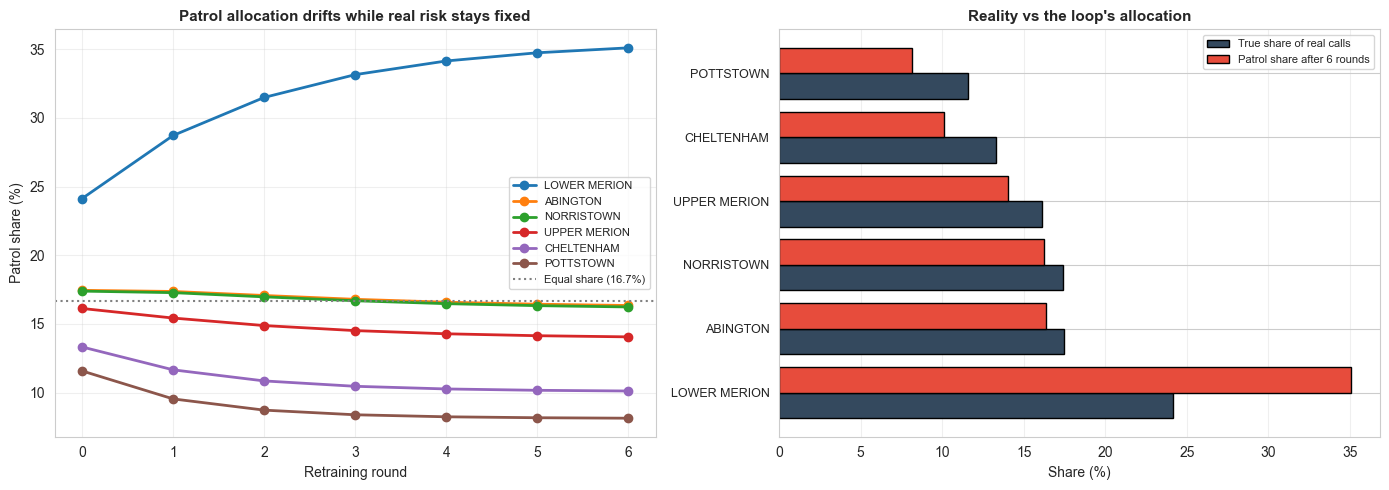

Largest drift between real call share and allocated patrol share: 10.97 percentage points,
produced entirely by feeding the system's own output back into it.
Break the loop by measuring incidence independently of where you deployed -
e.g. victim surveys, or holding out areas from the allocation policy.


In [8]:
# Why visualize: the runaway is a shape, not a number - the diverging lines
# make it obvious that nothing about real risk changed.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: each township's patrol share over the rounds of the loop.
for twp in top_twp.index:
    axes[0].plot(loop_df.index, loop_df[twp], marker='o', label=twp, linewidth=2)
axes[0].axhline(equal_share * 100, color='gray', linestyle=':',
                label=f'Equal share ({equal_share*100:.1f}%)')
axes[0].set_xlabel('Retraining round'); axes[0].set_ylabel('Patrol share (%)')
axes[0].set_title('Patrol allocation drifts while real risk stays fixed',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Right: where each township started vs where the loop left it.
y = np.arange(len(top_twp))
axes[1].barh(y - 0.2, true_share[top_twp.index].values, 0.4,
             label='True share of real calls', color='#34495e', edgecolor='black')
axes[1].barh(y + 0.2, final_share[top_twp.index].values, 0.4,
             label=f'Patrol share after {ROUNDS} rounds', color='#e74c3c',
             edgecolor='black')
axes[1].set_yticks(y); axes[1].set_yticklabels(top_twp.index, fontsize=9)
axes[1].set_xlabel('Share (%)')
axes[1].set_title('Reality vs the loop\'s allocation', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

drift = (final_share - true_share).abs().max()
print(f"Largest drift between real call share and allocated patrol share: "
      f"{drift:.2f} percentage points,")
print(f"produced entirely by feeding the system's own output back into it.")
print(f"Break the loop by measuring incidence independently of where you deployed -")
print(f"e.g. victim surveys, or holding out areas from the allocation policy.")

## Part 5: Case Study 4 - Who Does a Fraud Model Actually Protect?

Fair-lending regulators ask whether a model's decisions land differently on different
groups. We ask that question of a **real** financial model on **real** transactions:
the bundled 16,000-payment sample of a 284,807-payment file, with genuine fraud labels
(the features are PCA components, because the issuer would not release raw transaction
details - a privacy constraint that is itself a real-world fact about this kind of audit).

**Twenty-eight** of those payments are frauds. Hold that number: it is not a limitation
of the exercise, it is the ordinary condition of a real fairness audit, and it decides
what this case study is able to conclude.

The dataset has no demographic columns, so we group by something it does record:
**transaction size**. Transaction size is a well-known socio-economic proxy, and
"which customers does the fraud system protect, and which does it inconvenience"
is a genuine fairness question that banks are audited on.

Watch which metric flags the problem - and which one says everything is fine.

In [9]:
# Why this case: a real model on real financial data. The fairness question is not
# "is accuracy high" but "does protection reach everyone equally".

# Step 5: Audit a real fraud-detection model across transaction-size groups
from sklearn.model_selection import cross_val_predict, StratifiedKFold

print("\n" + "="*80)
print("CASE STUDY 4: Disparate Protection in Real Fraud Detection")
print("="*80)

# Read only the columns we use. The full 284,807-row file is 151 MB and is NOT in the
# repository, so `load` reads the 16,000-row sample that ships with it - drawn to keep the
# fraud rate intact (0.175% here against 0.173% in the original), which is the whole point
# of this dataset.
# WHY prefer="sample": it pins the lesson to the copy every clone contains, so every number
# below is reproducible on any machine, with or without a Kaggle account.
cc = load("creditcard_fraud", prefer="sample",
          usecols=['V1', 'V2', 'V3', 'V4', 'V10', 'V11', 'V12', 'V14',
                   'V17', 'Amount', 'Class'])
print(f"\nReal transactions loaded: {len(cc):,}")
print(f"Real fraud cases: {int(cc['Class'].sum()):,} "
      f"({cc['Class'].mean():.4%} of all transactions)")
print(f"This is REAL class imbalance - roughly 1 fraud in "
      f"{round(len(cc) / cc['Class'].sum()):,} transactions.")

# Use every transaction in the sample: 28 frauds is already too few to discard any.
sample = cc.sample(frac=1, random_state=42)
print(f"\nWorking sample: {len(sample):,} transactions "
      f"({int(sample['Class'].sum())} real frauds, "
      f"{int((sample['Class'] == 0).sum()):,} legitimate)")

# Group customers by transaction size - our socio-economic proxy.
sample['size_group'] = pd.qcut(sample['Amount'], 3,
                               labels=['small payments', 'medium payments',
                                       'large payments'])
print("\nReal fraud rate within each transaction-size group:")
for g, sub in sample.groupby('size_group', observed=True):
    print(f"  {g:<17}: {sub['Class'].mean():.2%} fraud   (n={len(sub):,}, "
          f"median amount ${sub['Amount'].median():.2f})")

# Train exactly the model a fraud team would ship, with no fairness step - but score it
# with 5-fold OUT-OF-FOLD predictions instead of one 70/30 split.
# WHY: there are 28 frauds in the entire sample. A single 30% test split holds out about
# eight of them, which leaves one or two per transaction-size group - too few to compute a
# detection rate from at all. Out-of-fold scoring gives every one of the 28 frauds a
# prediction from a model that never saw it, which is the most evidence this data can
# honestly supply. It is still very little, and that turns out to be the finding.
X = sample.drop(columns=['Class', 'size_group'])
y = sample['Class']
fraud_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pred = cross_val_predict(fraud_model, X, y,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42))

audit = X.copy()
audit['actual'] = y.values
audit['predicted'] = pred
audit['size_group'] = sample['size_group'].values

print(f"\nOverall out-of-fold accuracy: "
      f"{(audit['actual'] == audit['predicted']).mean():.4f}")
print(f"A number like that is why accuracy is the wrong metric here - predicting")
print(f"'never fraud' would already score {1 - y.mean():.2%}.\n")

print("-"*80)
print("PER-GROUP AUDIT")
print("-"*80)
print(f"{'Group':<17}{'n':>7}{'Frauds':>8}{'Detection (TPR)':>18}{'False alarms (FPR)':>21}")
group_stats = {}
for g, gd in audit.groupby('size_group', observed=True):
    tp = ((gd['actual'] == 1) & (gd['predicted'] == 1)).sum()
    fn = ((gd['actual'] == 1) & (gd['predicted'] == 0)).sum()
    fp = ((gd['actual'] == 0) & (gd['predicted'] == 1)).sum()
    tn = ((gd['actual'] == 0) & (gd['predicted'] == 0)).sum()
    tpr = tp / max(tp + fn, 1); fpr = fp / max(fp + tn, 1)
    group_stats[g] = {'TPR': tpr, 'FPR': fpr, 'n': len(gd), 'frauds': tp + fn,
                      'missed': fn, 'blocked': fp, 'legit': fp + tn}
    print(f"{str(g):<17}{len(gd):>7,}{tp+fn:>8}{tpr:>17.1%}{fpr:>20.2%}")

tprs = {g: s['TPR'] for g, s in group_stats.items()}
fprs = {g: s['FPR'] for g, s in group_stats.items()}
tpr_gap = max(tprs.values()) - min(tprs.values())
fpr_gap = max(fprs.values()) - min(fprs.values())
print(f"\n  Detection-rate (TPR) disparity : {tpr_gap:.4f}")
print(f"  False-alarm (FPR) disparity    : {fpr_gap:.4f}   "
      f"({fpr_gap*100:.3f} percentage points)")

n_legit_total = sum(s['legit'] for s in group_stats.values())
fewest_frauds = min(s['frauds'] for s in group_stats.values())

print("\n💡 THE LESSON: read both columns - and read the COUNTS beside them.")
print(f"   The false-alarm rates are nearly identical ({fpr_gap*100:.3f} percentage")
print(f"   points apart, on rates already below 0.1%), and that number is PRECISE:")
print(f"   it rests on {n_legit_total:,} legitimate transactions. A fairness report")
print(f"   built on false-alarm parity alone would sign this system off - and on the")
print(f"   evidence available, it would be entitled to.")
print(f"\n   The DETECTION rates differ by {tpr_gap*100:.1f} percentage points, which sounds")
print(f"   like the finding of the audit until you look at what produced it:")
for g in group_stats:
    s = group_stats[g]
    print(f"      {str(g):<17}{s['frauds']:>3} frauds in the whole sample, "
          f"{s['frauds'] - s['missed']} caught -> TPR {s['TPR']:.0%}")
print(f"\n   A rate computed from {fewest_frauds} case(s) is not a measurement. Equal")
print(f"   treatment of the innocent is not the same as equal protection of the")
print(f"   victims - but on this data only the FIRST of the two can actually be")
print(f"   measured, and saying so out loud IS the audit's finding. The fix is not a")
print(f"   cleverer metric; it is more labelled fraud, or an interval printed beside")
print(f"   every rate so that nobody mistakes {tpr_gap*100:.0f} points of noise for a result.")


CASE STUDY 4: Disparate Protection in Real Fraud Detection
creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.

Real transactions loaded: 16,000
Real fraud cases: 28 (0.1750% of all transactions)
This is REAL class imbalance - roughly 1 fraud in 571 transactions.

Working sample: 16,000 transactions (28 real frauds, 15,972 legitimate)

Real fraud rate within each transaction-size group:
  small payments   : 0.33% fraud   (n=5,521, median amount $2.00)
  medium payments  : 0.04% fraud   (n=5,149, median amount $22.66)
  large payments   : 0.15% fraud   (n=5,330, median amount $123.41)



Overall out-of-fold accuracy: 0.9990
A number like that is why accuracy is the wrong metric here - predicting
'never fraud' would already score 99.83%.

--------------------------------------------------------------------------------
PER-GROUP AUDIT
--------------------------------------------------------------------------------
Group                  n  Frauds   Detection (TPR)   False alarms (FPR)
small payments     5,521      18            61.1%               0.05%
medium payments    5,149       2           100.0%               0.02%
large payments     5,330       8            50.0%               0.02%

  Detection-rate (TPR) disparity : 0.5000
  False-alarm (FPR) disparity    : 0.0004   (0.036 percentage points)

💡 THE LESSON: read both columns - and read the COUNTS beside them.
   The false-alarm rates are nearly identical (0.036 percentage
   points apart, on rates already below 0.1%), and that number is PRECISE:
   it rests on 15,972 legitimate transactions. A fairness report
 

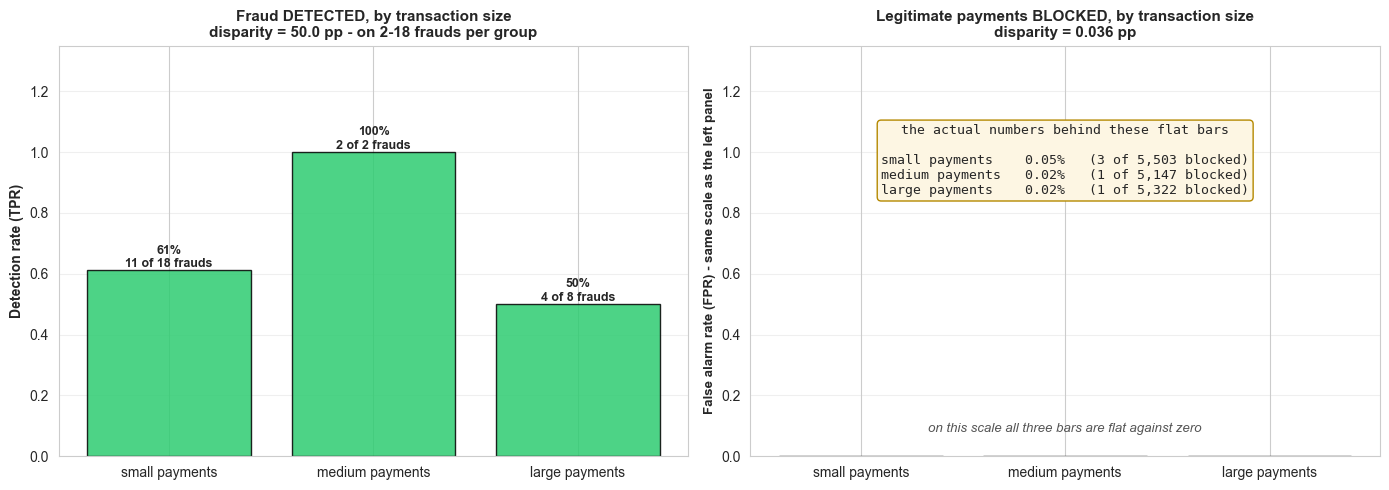

Left panel: uneven. Right panel: flat against the floor of the SAME axis.
Same model, same out-of-fold predictions, opposite verdicts.
And look at what the 0.036 pp 'false-alarm disparity' is made of:
   small payments   3 legitimate payment(s) blocked out of 5,503
   medium payments  1 legitimate payment(s) blocked out of 5,147
   large payments   1 legitimate payment(s) blocked out of 5,322
A gap of 2 transaction(s). Reported as a percentage on a tight enough
axis it would look like a finding; reported as a count it is noise. Always
print the counts next to the rate.

Then apply exactly the same test to the LEFT panel, which looks like the
real finding. Its bars are built from 18, 2, 8 frauds. They are
noise too. The difference is that the flat panel is flat AND well measured,
while the dramatic panel is dramatic AND unmeasurable - and only one of those
two facts will make it into the summary slide unless you put it there.

This is the single most practical thing to take from Unit 2 

In [10]:
# Why visualize: one panel of uneven bars beside one panel of flat bars, drawn on the
# SAME axis, is the clearest possible statement of "pick the right metric" - and writing
# the CASE COUNTS onto both panels is the clearest possible statement of the second
# lesson, that a rate without its denominator is not evidence of anything.

groups_cc = list(group_stats.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(g) for g in groups_cc], [group_stats[g]['TPR'] for g in groups_cc],
            color='#2ecc71', alpha=0.85, edgecolor='black')
for i, g in enumerate(groups_cc):
    st = group_stats[g]
    axes[0].text(i, st['TPR'],
                 f"{st['TPR']:.0%}\n{st['frauds'] - st['missed']} of {st['frauds']} frauds",
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].set_ylim(0, 1.35)
axes[0].set_ylabel('Detection rate (TPR)', fontweight='bold')
axes[0].set_title(f'Fraud DETECTED, by transaction size\ndisparity = {tpr_gap*100:.1f} pp '
                  f'- on {min(s["frauds"] for s in group_stats.values())}-'
                  f'{max(s["frauds"] for s in group_stats.values())} frauds per group',
                  fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Deliberately the SAME y-axis as the left panel. Giving this panel its own
# zoomed axis would make three near-zero rates look like a disagreement; on the
# shared scale you can see they are all flat against the floor. The counts that
# produced these rates are printed inside the panel instead, because a rate this
# small is unreadable without the number of transactions behind it.
axes[1].bar([str(g) for g in groups_cc], [group_stats[g]['FPR'] for g in groups_cc],
            color='#e74c3c', alpha=0.85, edgecolor='black')
axes[1].set_ylim(0, 1.35)
axes[1].set_ylabel('False alarm rate (FPR) - same scale as the left panel',
                   fontweight='bold', fontsize=9.5)
axes[1].set_title(f'Legitimate payments BLOCKED, by transaction size\n'
                  f'disparity = {fpr_gap*100:.3f} pp', fontsize=11, fontweight='bold')
axes[1].text(0.5, 0.06, 'on this scale all three bars are flat against zero',
             transform=axes[1].transAxes, ha='center', fontsize=9.5,
             style='italic', color='#555555')
axes[1].grid(axis='y', alpha=0.3)

# No zoomed inset here on purpose. A magnified axis would turn a one-transaction
# difference into a picture of a disagreement. Instead we print the rates WITH the
# counts behind them, which is the only form in which they can be read honestly.
rows_txt = "\n".join(
    f"{str(g):<16}{group_stats[g]['FPR']:>7.2%}   "
    f"({group_stats[g]['blocked']} of {group_stats[g]['legit']:,} blocked)"
    for g in groups_cc)
axes[1].text(0.5, 0.72, "the actual numbers behind these flat bars\n\n" + rows_txt,
             transform=axes[1].transAxes, ha='center', va='center',
             family='monospace', fontsize=9.5,
             bbox=dict(boxstyle='round', facecolor='#fdf6e3', edgecolor='#b58900'))

plt.tight_layout()
plt.show()

print("Left panel: uneven. Right panel: flat against the floor of the SAME axis.")
print("Same model, same out-of-fold predictions, opposite verdicts.")
print(f"And look at what the {fpr_gap*100:.3f} pp 'false-alarm disparity' is made of:")
for g in groups_cc:
    print(f"   {str(g):<17}{group_stats[g]['blocked']} legitimate payment(s) blocked "
          f"out of {group_stats[g]['legit']:,}")
spread = (max(group_stats[g]['blocked'] for g in groups_cc)
          - min(group_stats[g]['blocked'] for g in groups_cc))
print(f"A gap of {spread} transaction(s). Reported as a percentage on a tight enough")
print("axis it would look like a finding; reported as a count it is noise. Always")
print("print the counts next to the rate.")
print("\nThen apply exactly the same test to the LEFT panel, which looks like the")
print("real finding. Its bars are built from "
      f"{', '.join(str(group_stats[g]['frauds']) for g in groups_cc)} frauds. They are")
print("noise too. The difference is that the flat panel is flat AND well measured,")
print("while the dramatic panel is dramatic AND unmeasurable - and only one of those")
print("two facts will make it into the summary slide unless you put it there.")
print("\nThis is the single most practical thing to take from Unit 2 - a fairness")
print("verdict is only as honest as the metric, the axis, and the sample size you")
print("chose before you looked.")


## 💬 Discuss

Four cases, four numbers your own run produced. Argue from them.

1. **Which number goes on the box?** *Gender Shades*: the three audited systems averaged
   **9.5 %** reported error and **30.0 %** error on darker-skinned women — a factor of
   **3.2**. Suppose you are the product manager. What single accuracy figure, if any, is
   honest to publish? If your answer is "publish the disaggregated table", say what you do
   when the sales team replies that no competitor publishes one and the tender is decided on
   the headline number. NIST's reply to that argument was to test everybody; is
   mandatory third-party testing the only workable answer?
2. **A fairness verdict that reverses on the metric — and neither half is safe.**
   Case Study 4: the fraud model's false-alarm rates across transaction-size groups differ
   by **0.036 percentage points**, measured on **15,972 legitimate payments** — it looks
   fair, and it is *precisely* measured. Its detection rates differ by **50 points**,
   measured on **18, 2 and 8 frauds** — it looks catastrophic, and it is measured on almost
   nothing. Same model, same run. A bank's compliance officer asks which one to report to
   the regulator. Answer — and then notice that "report the one with a sample size behind
   it" quietly reports the metric that protects nobody. Then the harder question: what
   stops a firm from choosing its metric *after* seeing which one passes? Would you accept
   "we pre-registered the metric" as a control, or does that need to be someone else's job?
3. **Nobody's fault, still a harm.** Case Study 3 held real incidence perfectly constant and
   the allocation still drifted by **11.0 percentage points**, purely from feeding the
   system's own output back to itself. Every individual step was a policy nobody would call
   unfair. So who is responsible for the outcome — the analyst who wrote the allocation rule,
   the commander who approved it, or nobody? And where else in your own work does a system
   get retrained on data its own decisions produced? (Recommenders, credit limits, and hiring
   funnels all qualify.)


## ⚠️ Where this breaks

Case studies teach pattern recognition. They also mislead in predictable ways, and three of
the four above carry a caveat you should be able to state.

- **Transcribed audit tables age.** The *Gender Shades* figures are the systems **as
  audited in 2017–18**. All three vendors changed their models afterwards; NIST's ongoing
  FRVT reports show the most accurate current algorithms have much smaller differentials.
  Quoting 34.7 % as a fact about face recognition *today* is wrong. What survives is the
  **method** — disaggregate, then look — not the number.
- **Titanic is a confounded proxy, deliberately.** "Women and children first" was stated
  policy, so a large part of the 55.3-point sex gap is a policy operating as intended, and
  ticket class confounds the rest. That is why it is honest teaching material and why no
  conclusion about hiring, lending or policing follows from it.
- **The feedback loop is a simulation of a policy, not a measurement of any police force.**
  The 911 call volumes are real Montgomery County data — the bundled 1-in-27 sample, so the
  *shares* are trustworthy and the absolute counts are 27 times smaller than the county's
  real ones. The allocation rule is ours, and we held true incidence constant *by
  construction* so the drift would be unambiguous. It demonstrates that the mechanism is
  real. It does not measure how large the effect is anywhere in particular.
- **Transaction size is a proxy for socio-economic status, and a weak one.** The credit-card
  file has no demographic columns at all, so Case Study 4 audits the group it can see, not
  the group a regulator cares about. If you present this as a fair-lending analysis, expect
  to be asked for the demographics — and to have to say you do not have them.
- **Case Study 4's detection rates are not quotable, and the notebook says so in its own
  output.** The bundled sample holds 28 frauds in total, so the three per-group rates rest
  on 18, 2 and 8 cases. A 50-point "disparity" built like that is noise wearing a
  percentage sign. Do not carry those three numbers out of this notebook; carry the habit
  of printing the denominator beside every rate. (If you download the full 284,807-row file
  into `Course 04/datasets/raw/` you get 492 frauds — but change `prefer="sample"` to
  `prefer="auto"` first, or the loader will keep using the sample, exactly as it was told to.)

**When a case study is the wrong tool entirely:** when the question is whether *your* system
is biased. No amount of reading about COMPAS, Amazon or Gender Shades substitutes for
running Notebook 01's metrics on your own held-out set, with your own group sizes printed
next to them.


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We learned techniques for detecting and mitigating bias, but hadn't applied them to real recorded evidence.

**AFTER this notebook**: We analysed four case studies, **every one of them on real data**:
- ✅ **Gender Shades (published audit)**: commercial classifiers whose overall error rates
  were 6.3 %, 10.0 % and 12.1 % while their error rate on darker-skinned females reached 34.7%
- ✅ **Titanic (real selection record)**: a large, real, *confounded* disparity - and the
  intersectional table that neither single-axis view contains
- ✅ **Montgomery County 911 calls (real dispatch data)**: a patrol-allocation feedback
  loop that concentrated resources while true incidence never moved
- ✅ **Credit-card fraud (real transactions)**: false-alarm rates equal to within 0.036
  points on 15,972 payments, beside detection rates that differ by 50 points on 28 frauds
  — a gap you can see and cannot report

### Key Takeaways
1. **Audit at the intersection.** Case Study 1's headline numbers were fine; the harm was
   in a subgroup no single-axis report examines. Case Study 2 reproduced the same pattern
   on completely different data.
2. **Disparity is not automatically discrimination.** Case Study 2's sex gap is partly a
   stated policy. Real auditing means separating the explained part from the unexplained
   part, and being able to defend the split.
3. **Some harm has no biased coefficient at all.** Case Study 3's loop used a policy
   nobody would call unfair, applied to real data, and still ran away. Ask what happens
   when your model is retrained on data its own decisions produced.
4. **The metric you choose determines the verdict — and the sample size determines whether
   the verdict means anything.** Case Study 4 passed on false-alarm parity and appeared to
   fail on detection parity, same model and same run; but the passing metric rested on
   15,972 cases and the failing one on 28. Choose and justify the metric *before* you look
   at the result, and print the count beside every rate you report.
5. **The techniques from Notebooks 1-3 apply directly** to all four cases: per-group
   metrics found the gaps, and per-group thresholds are how systems like Case Study 4
   get repaired.

---

## ➡️ Next Steps

**Next notebook**: `05_fair_ai_development.ipynb` - integrate everything into a fair development workflow: inclusive data collection, bias-aware training, and human-in-the-loop review.

## 🔭 State of the field (2026)

The four cases above are the classical audit targets: a shipped classifier, a recorded selection
decision, an allocation policy, a scored financial model. In 2026 the system doing those jobs is
usually a general-purpose model, and the audits have followed it there. Hiring is the clearest
example — the résumé-screening failure this notebook could only *describe*, because the tool
Reuters reported Amazon abandoning in 2018 was never released, now has purpose-built instruments:
**PopResume** (2026) supplies a population-representative résumé dataset and audits LLM and VLM
screeners **causally**, separating a protected attribute's effect into business-necessity and
redlining paths rather than stopping at an outcome gap. The *Gender Shades* pattern also keeps
reappearing in new modalities: **VIBE** (2026) evaluates large audio-language models on real
recorded human speech and finds open-ended generative bias triggered by gender and accent cues —
in a place that multiple-choice speech benchmarks were not looking.

Notice what both teams actually did: **they built the right benchmark, then disaggregated the
result.** That is the method of this notebook, not a replacement for it. As ⚠️ *Where this breaks*
already warns, the transcribed numbers age; the procedure does not, and the procedure is what the
official plan examines.

- Yu, S., Park, J. & Moon, T. (2026). *PopResume: Causal Fairness Evaluation of LLM/VLM Resume Screeners with Population-Representative Dataset*. <https://arxiv.org/abs/2603.22714>
- Lin, Y.-C., Hirota, Y., Huang, S.-F. & Lee, H. (2026). *VIBE: Voice-Induced open-ended Bias Evaluation for Large Audio-Language Models via Real-World Speech*. <https://arxiv.org/abs/2604.17248>

---


## 📚 References

1. Buolamwini, J. & Gebru, T. (2018). *Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification*. FAT* 2018, PMLR 81. <https://proceedings.mlr.press/v81/buolamwini18a.html> — **the source of the Case Study 1 table (Table 4, "Error Rate (%)" rows), transcribed verbatim.**
2. Angwin, J., Larson, J., Mattu, S. & Kirchner, L. (2016). *Machine Bias*. ProPublica. <https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing>
3. Ensign, D., Friedler, S. A., Neville, S., Scheidegger, C. & Venkatasubramanian, S. (2018). *Runaway Feedback Loops in Predictive Policing*. FAT* 2018, PMLR 81. <https://arxiv.org/abs/1706.09847> — the mechanism modelled in Case Study 3.
4. Raji, I. D., Smart, A., White, R. N., et al. (2020). *Closing the AI Accountability Gap: Defining an End-to-End Framework for Internal Algorithmic Auditing*. FAT* 2020. <https://arxiv.org/abs/2001.00973>
5. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6). <https://arxiv.org/abs/1908.09635>
6. Dal Pozzolo, A., Caelen, O., Johnson, R. A. & Bontempi, G. (2015). *Calibrating Probability with Undersampling for Unbalanced Classification*. IEEE SSCI 2015. — the credit-card fraud dataset used in Case Study 4.
7. Yu, S., Park, J. & Moon, T. (2026). *PopResume: Causal Fairness Evaluation of LLM/VLM Resume Screeners with Population-Representative Dataset*. arXiv:2603.22714. <https://arxiv.org/abs/2603.22714> — the hiring audit this notebook could only describe, done properly: a population-representative résumé set that supports path-specific-effect auditing instead of an outcome gap alone.
8. Lin, Y.-C., Hirota, Y., Huang, S.-F. & Lee, H. (2026). *VIBE: Voice-Induced open-ended Bias Evaluation for Large Audio-Language Models via Real-World Speech*. arXiv:2604.17248. <https://arxiv.org/abs/2604.17248> — the *Gender Shades* method carried into audio: real recorded human speech, open-ended generation, bias triggered by gender and accent cues.
